## Functions

In [1]:
import wandb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict
 
WANDB_ENTITY = "alvomatias_project"
WANDB_PROJECT = "inventory_control"
 
 
# ---------------------------------------------------------------------------
# Data fetching
# ---------------------------------------------------------------------------
 
def fetch_sweep_runs(sweep_name: str) -> list:
    api = wandb.Api()
    sweep = api.sweep(f"{WANDB_ENTITY}/{WANDB_PROJECT}/{sweep_name}")
    runs = list(sweep.runs)
    print(f"Fetched {len(runs)} runs from sweep {sweep_name}")
    return runs
 
 
def compute_epoch_df(
    sweep_name: str,
    loss_metric: str,
    value_metrics: list[str],
    x_key: str = "stores",
    run_key: str = "run_idx",
    seed_key: str = "a_seed",
) -> pd.DataFrame:
    """
    Fetches all runs and returns a raw epoch-level DataFrame.
    One row per (x_val, run_val, seed_val, epoch).
 
    The optimality gap is computed as:
        opt_gap = loss[epoch] - floor(x_val, run_val)
    where floor = min loss across all seeds and epochs for that (x_val, run_val).
 
    Parameters
    ----------
    sweep_name    : W&B sweep ID
    loss_metric   : metric used to compute the optimality gap (also stored as a column)
    value_metrics : metrics to fetch and store as columns
    x_key         : config key for the grouping dimension (e.g. "stores")
    run_key       : config key identifying a unique policy (e.g. "run_idx")
    seed_key      : config key identifying the seed (e.g. "a_seed")
 
    Returns
    -------
    pd.DataFrame with columns:
        {x_key}, {run_key}, {seed_key}, epoch, {loss_metric}, opt_gap, *value_metrics
    Metrics that are missing for a given epoch are NaN.
    """
    runs = fetch_sweep_runs(sweep_name)
    all_keys = [loss_metric] + value_metrics
    identifier_keys = (x_key, run_key, seed_key)
 
    # --- Step 1: fetch histories ---
    run_data = {}
    for run in runs:
        cfg = run.config
        try:
            key = tuple(cfg[k] for k in identifier_keys)
        except KeyError as e:
            print(f"Skipping run {run.id}: missing config key {e}")
            continue
 
        history = run.history(keys=all_keys, pandas=True)
        if history.empty:
            continue
 
        available = [c for c in all_keys if c in history.columns]
        sub = history[available].dropna(subset=[loss_metric]).reset_index(drop=True)
        if sub.empty:
            continue
 
        run_data[key] = sub
 
    if not run_data:
        raise ValueError("No valid run data found.")
 
    print(f"Valid runs: {len(run_data)}")
 
    # --- Step 2: compute floor per (x_val, run_val) ---
    floor: dict[tuple, float] = defaultdict(lambda: np.inf)
    for (x_val, run_val, seed_val), sub in run_data.items():
        policy_key = (x_val, run_val)
        floor[policy_key] = min(floor[policy_key], float(sub[loss_metric].min()))
 
    # --- Step 3: build epoch-level rows ---
    records = []
    for (x_val, run_val, seed_val), sub in run_data.items():
        best    = floor[(x_val, run_val)]
        opt_gap = sub[loss_metric].values - best
 
        chunk = sub.copy()
        chunk.insert(0, x_key,    x_val)
        chunk.insert(1, run_key,  run_val)
        chunk.insert(2, seed_key, seed_val)
        chunk.insert(3, "epoch",  np.arange(len(chunk)))
        chunk["opt_gap"] = opt_gap
        records.append(chunk)
 
    result = pd.concat(records, ignore_index=True)
 
    # Reorder: identifiers first, then opt_gap, then metrics
    id_cols     = [x_key, run_key, seed_key, "epoch", loss_metric, "opt_gap"]
    metric_cols = [c for c in result.columns if c not in id_cols]
    return result[id_cols + metric_cols]
 
 
# ---------------------------------------------------------------------------
# Derived metrics (epoch-level)
# ---------------------------------------------------------------------------
 
def add_derived_metrics(
    epoch_df: pd.DataFrame,
    derived: dict[str, callable],
) -> pd.DataFrame:
    """
    Adds derived metric columns to the epoch-level DataFrame.
    Each callable receives the DataFrame and returns a Series.
 
    Parameters
    ----------
    epoch_df : output of compute_epoch_df
    derived  : dict mapping new column name -> callable(df) -> pd.Series
 
    Example
    -------
    derived = {
        "grad_ratio/pathwise_vs_cross": lambda df: (
            df["train/grad_norm/continuous/pathwise/true"]
            / df["train/grad_norm/continuous/cross_ppo/true"]
        ),
    }
 
    Returns
    -------
    epoch_df with new columns appended (original df is not mutated).
    """
    result = epoch_df.copy()
    for name, fn in derived.items():
        try:
            result[name] = fn(result)
        except Exception as e:
            print(f"Could not compute derived metric '{name}': {e}")
    return result
 
 
# ---------------------------------------------------------------------------
# Bucketing + aggregation
# ---------------------------------------------------------------------------
 
def compute_bucketed_metrics(
    epoch_df: pd.DataFrame,
    value_metrics: list[str],
    x_key: str = "stores",
    run_key: str = "run_idx",
    seed_key: str = "a_seed",
    bucket_metric: str = "opt_gap",
    bucket_width: float = 5.0,
) -> pd.DataFrame:
    """
    Aggregates epoch-level data into buckets using two-stage averaging:
      Stage 1: mean per (run_key, seed_key, bucket)  — equal epoch weight per run
      Stage 2: simple average across (run_key, seed_key) — equal run weight
 
    Parameters
    ----------
    epoch_df      : output of compute_epoch_df (optionally with derived columns added)
    value_metrics : columns to aggregate
    x_key         : grouping dimension column (e.g. "stores")
    run_key       : run identity column (e.g. "run_idx")
    seed_key      : seed identity column (e.g. "a_seed")
    bucket_metric : column to bucketize on (e.g. "opt_gap" or any value metric)
    bucket_width  : width of each bucket
 
    Returns
    -------
    Wide-format pd.DataFrame with columns:
        {x_key}, bucket_left, bucket_right, {metric_1}, {metric_2}, ...
    One row per (x_val, bucket). Missing metric/bucket combos are NaN.
    """
    df = epoch_df.copy()
    df["bucket_left"] = (df[bucket_metric] // bucket_width) * bucket_width
 
    agg_records = []
    for x_val in df[x_key].unique():
        sub_x = df[df[x_key] == x_val]
 
        bucket_agg: dict[float, dict] = {}
        for metric in value_metrics:
            if metric not in sub_x.columns:
                continue
 
            rows = sub_x[[run_key, seed_key, "bucket_left", metric]].dropna(subset=[metric])
            if rows.empty:
                continue
 
            # Stage 1: mean per (run, seed, bucket)
            per_run = (
                rows.groupby([run_key, seed_key, "bucket_left"])[metric]
                .mean()
                .reset_index()
                .rename(columns={metric: "run_mean"})
            )
 
            # Stage 2: simple average across runs
            agg = (
                per_run.groupby("bucket_left")["run_mean"]
                .mean()
                .reset_index()
                .rename(columns={"run_mean": metric})
            )
 
            for _, row in agg.iterrows():
                bl = row["bucket_left"]
                if bl not in bucket_agg:
                    bucket_agg[bl] = {x_key: x_val, "bucket_left": bl,
                                      "bucket_right": bl + bucket_width}
                bucket_agg[bl][metric] = row[metric]
 
        agg_records.extend(bucket_agg.values())
 
    result = pd.DataFrame(agg_records)
    id_cols     = [x_key, "bucket_left", "bucket_right"]
    metric_cols = [c for c in result.columns if c not in id_cols]
    result = result[id_cols + metric_cols]
    result = result.sort_values([x_key, "bucket_left"]).reset_index(drop=True)
    return result
 
 
# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------
 
def plot_metric_vs_x(
    df: pd.DataFrame,
    x_key: str,
    filter_key: str,
    filter_value: float,
    value_metrics: list[str],
    bucket_width: float,
    xlabel: str = None,
    ylabel: str = "Mean value",
    title: str | None = None,
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    show_legend: bool = True,
    legend_names: list[str] | None = None,
    out_file: str | None = None,
) -> None:
    """
    Generic plot: x_key on x-axis, filter_key fixed to filter_value, one line per metric.
    Line labels use the last three slash-separated sections of the metric name by default.

    Typical usage A — x=stores, filter on gap bucket:
        plot_metric_vs_x(df, x_key="stores", filter_key="bucket_left", filter_value=0.0, ...)

    Typical usage B — x=gap bucket, filter on stores:
        plot_metric_vs_x(df, x_key="bucket_left", filter_key="stores", filter_value=10, ...)

    Parameters
    ----------
    df           : output of compute_bucketed_metrics
    x_key        : column to use as x-axis (e.g. "stores" or "bucket_left")
    filter_key   : column to filter on (e.g. "bucket_left" or "stores")
    filter_value : value to keep in filter_key
    value_metrics: metric columns to plot (controls order)
    bucket_width : used only for auto-generating the title
    xlabel       : x-axis label (defaults to x_key)
    ylabel       : y-axis label
    title        : plot title (auto-generated if None)
    xlim         : optional (xmin, xmax)
    ylim         : optional (ymin, ymax)
    show_legend  : if True (default), show the legend
    legend_names : optional list of display names, one per entry in value_metrics,
                   in the same order; falls back to the last 3 metric name segments
    out_file     : if given, saves the figure here
    """
    if legend_names is not None and len(legend_names) != len(value_metrics):
        raise ValueError(
            f"legend_names has {len(legend_names)} entries but value_metrics has "
            f"{len(value_metrics)}. They must match."
        )

    filtered = df[np.isclose(df[filter_key].astype(float), float(filter_value))]
    if filtered.empty:
        print(f"No data for {filter_key}={filter_value}.")
        print(f"Available values: {sorted(df[filter_key].unique())}")
        return

    filtered = filtered.sort_values(x_key)

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, metric in enumerate(value_metrics):
        if metric not in filtered.columns:
            print(f"  No data for metric: {metric}")
            continue
        sub   = filtered[[x_key, metric]].dropna(subset=[metric])
        label = legend_names[i] if legend_names is not None else "/".join(metric.split("/")[-3:])
        ax.plot(sub[x_key], sub[metric], marker="o", label=label)

    if title is None:
        if filter_key == "bucket_left":
            title = f"opt gap ∈ [{filter_value:.1f}, {filter_value + bucket_width:.1f})"
        else:
            title = f"{filter_key}={filter_value}"

    ax.set_xlabel(xlabel if xlabel is not None else x_key)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if show_legend:
        ax.legend()
    plt.tight_layout()

    if out_file:
        plt.savefig(out_file, dpi=150)
        print(f"Saved to {out_file}")
    plt.show()

In [2]:
def plot_metric_vs_x_multi(
    df: pd.DataFrame,
    x_key: str,
    filter_key: str,
    filter_values: list[float],
    value_metrics: list[str],
    bucket_width: float,
    xlabel: str = None,
    ylabel: str = "Mean value",
    title: str | None = None,
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    out_file: str | None = None,
) -> None:
    """
    Like plot_metric_vs_x, but plots one line per filter_value instead of one line per metric.
    Useful when you want to compare the same metric across multiple filter conditions
    (e.g. different store counts, or different opt-gap buckets).

    When len(value_metrics) == 1, each line is labeled by its filter_value.
    When len(value_metrics) > 1, lines are labeled "{filter_value} | {metric_label}".

    Parameters
    ----------
    df            : output of compute_bucketed_metrics
    x_key         : column to use as x-axis (e.g. "stores" or "bucket_left")
    filter_key    : column whose values define the lines (e.g. "stores" or "bucket_left")
    filter_values : list of values to keep from filter_key (one line each)
    value_metrics : metric columns to plot
    bucket_width  : used for auto-generating the title
    xlabel        : x-axis label (defaults to x_key)
    ylabel        : y-axis label
    title         : plot title (auto-generated if None)
    xlim          : optional (xmin, xmax)
    ylim          : optional (ymin, ymax)
    out_file      : if given, saves the figure here
    """
    multi_metric = len(value_metrics) > 1

    # Cycle colours across filter values; use linestyles across metrics
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    linestyles = ["-", "--", "-.", ":"]

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, fv in enumerate(filter_values):
        filtered = df[np.isclose(df[filter_key].astype(float), float(fv))]
        if filtered.empty:
            print(f"No data for {filter_key}={fv}. "
                  f"Available: {sorted(df[filter_key].unique())}")
            continue
        filtered = filtered.sort_values(x_key)
        color = color_cycle[i % len(color_cycle)]

        # Build a short label for the filter value
        if filter_key == "bucket_left":
            fv_label = f"gap=[{fv:.0f},{fv + bucket_width:.0f})"
        else:
            fv_label = f"{filter_key}={fv}"

        for j, metric in enumerate(value_metrics):
            if metric not in filtered.columns:
                print(f"  No data for metric: {metric}")
                continue
            sub = filtered[[x_key, metric]].dropna(subset=[metric])
            metric_label = "/".join(metric.split("/")[-3:])
            label = f"{fv_label} | {metric_label}" if multi_metric else fv_label
            ax.plot(
                sub[x_key], sub[metric],
                marker="o",
                color=color,
                linestyle=linestyles[j % len(linestyles)],
                label=label,
            )

    if title is None:
        fv_str = ", ".join(
            f"[{fv:.0f},{fv + bucket_width:.0f})" if filter_key == "bucket_left"
            else str(fv)
            for fv in filter_values
        )
        title = f"{filter_key} ∈ {{{fv_str}}}"

    ax.set_xlabel(xlabel if xlabel is not None else x_key)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend()
    plt.tight_layout()

    if out_file:
        plt.savefig(out_file, dpi=150)
        print(f"Saved to {out_file}")
    plt.show()

In [3]:
def plot_scatter_with_regression(
    df: pd.DataFrame,
    x_metric: str,
    y_metric: str,
    color_key: str,
    bucket_width: float,
    filter_key: str | None = None,
    filter_value: float | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    title: str | None = None,
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    x_log: bool = False,
    point_size: float = 50,
    alpha: float = 0.6,
    jitter: float = 0.0,
    show_regression: bool = True,
    regression_degree: int = 1,
    regime_x: tuple | float | None = None,
    cmap_name: str = "viridis",
    out_file: str | None = None,
) -> None:
    """
    Scatterplot of x_metric vs y_metric, color-coded by color_key using a
    sequential colormap (darker = higher value), with an optional polynomial
    regression line and a shaded regime band.

    Each point is assumed to be an already-aggregated (color_key, bucket) mean,
    so no further binning is applied.

    Parameters
    ----------
    df                : output of compute_bucketed_metrics
    x_metric          : column for x-axis
    y_metric          : column for y-axis
    color_key         : column whose values determine point colors (e.g. "stores")
    bucket_width      : used for auto title when filter_key == "bucket_left"
    filter_key        : column to filter on before plotting; None = no filter
    filter_value      : value to keep in filter_key
    xlabel            : x-axis label
    ylabel            : y-axis label
    title             : plot title (auto-generated if None)
    xlim              : optional (xmin, xmax)
    ylim              : optional (ymin, ymax)
    x_log             : if True, use log scale on x-axis
    point_size        : marker size
    alpha             : point opacity
    jitter            : std of Gaussian noise added to x and y (0 = disabled)
    show_regression   : if True, overlay a polynomial regression line across all points
    regression_degree : degree of the polynomial fit (1 = linear, 2 = quadratic)
    regime_x          : marks the experimental regime on the x-axis.
                        - float : a single vertical dashed line
                        - tuple : a shaded band (x_lo, x_hi)
                        - None  : disabled
    cmap_name         : matplotlib colormap name for the color_key gradient
                        (e.g. "viridis", "plasma", "YlOrRd", "Blues")
    out_file          : if given, saves the figure here
    """
    df = df.copy()

    # --- Optional filter ---
    if filter_key is not None:
        if filter_value is None:
            raise ValueError("filter_value must be provided when filter_key is set.")
        df = df[np.isclose(df[filter_key].astype(float), float(filter_value))]
        if df.empty:
            print(f"No data for {filter_key}={filter_value}.")
            print(f"Available values: {sorted(df[filter_key].unique())}")
            return

    df = df.dropna(subset=[x_metric, y_metric])
    if df.empty:
        print("No data after dropping NaNs.")
        return

    # --- Color map (sequential, one shade per color_key value) ---
    color_values = sorted(df[color_key].unique())
    cmap         = plt.cm.get_cmap(cmap_name)
    norm = plt.matplotlib.colors.LogNorm(vmin=min(color_values), vmax=max(color_values))
    color_map    = {v: cmap(norm(v)) for v in color_values}

    fig, ax = plt.subplots(figsize=(7, 5))
    rng = np.random.default_rng(seed=0)

    # --- Scatter ---
    for val in color_values:
        sub    = df[df[color_key] == val]
        x_vals = sub[x_metric].values.astype(float)
        y_vals = sub[y_metric].values.astype(float)

        if jitter > 0.0:
            x_vals = x_vals + rng.normal(0, jitter, size=len(x_vals))
            y_vals = y_vals + rng.normal(0, jitter, size=len(y_vals))

        ax.scatter(
            x_vals, y_vals,
            color=color_map[val],
            alpha=alpha,
            edgecolors="none",
            s=point_size,
            zorder=2,
        )

    # --- Colorbar ---
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(color_key)
    cbar.set_ticks(color_values)
    cbar.set_ticklabels(color_values)

    # --- Regression line ---
    if show_regression:
        all_x   = df[x_metric].values.astype(float)
        all_y   = df[y_metric].values.astype(float)
        x_fit   = np.log(all_x) if x_log else all_x
        coeffs  = np.polyfit(x_fit, all_y, deg=regression_degree)
        poly    = np.poly1d(coeffs)

        x_range     = np.linspace(all_x.min(), all_x.max(), 300)
        x_range_fit = np.log(x_range) if x_log else x_range
        y_range     = poly(x_range_fit)

        r, pval   = pearsonr(x_fit, all_y)
        reg_label = f"fit (deg={regression_degree}, r={r:.2f})"
        ax.plot(
            x_range, y_range,
            color="black", linewidth=1.8,
            linestyle="--", label=reg_label,
            zorder=3,
        )
        ax.legend(fontsize=8)

    # --- Regime marker ---
    if regime_x is not None:
        if isinstance(regime_x, tuple):
            ax.axvspan(
                regime_x[0], regime_x[1],
                alpha=0.12, color="gray",
                label="experimental regime",
                zorder=1,
            )
        else:
            ax.axvline(
                regime_x, color="gray",
                linewidth=1.5, linestyle=":",
                label=f"experimental regime (x={regime_x:.2f})",
                zorder=1,
            )

    # --- Log scale ---
    if x_log:
        ax.set_xscale("log")

    # --- Labels and title ---
    ax.set_xlabel(xlabel if xlabel is not None else "/".join(x_metric.split("/")[-3:]))
    ax.set_ylabel(ylabel if ylabel is not None else "/".join(y_metric.split("/")[-3:]))

    if title is None:
        if filter_key == "bucket_left" and filter_value is not None:
            title = f"opt gap ∈ [{filter_value:.1f}, {filter_value + bucket_width:.1f})"
        elif filter_key is not None and filter_value is not None:
            title = f"{filter_key}={filter_value}"
        else:
            title = f"{'/'.join(x_metric.split('/')[-2:])} vs {'/'.join(y_metric.split('/')[-2:])}"

    ax.set_title(title)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    plt.tight_layout()

    if out_file:
        plt.savefig(out_file, dpi=150)
        print(f"Saved to {out_file}")
    plt.show()

## Run functions

### Cosine similarity experiments

In [4]:
# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    # SWEEP_NAME   = "2afiqo15"
    # SWEEP_NAME   = "n8ffl8wg"
    SWEEP_NAME   = "7gbdtzpq"
    # SWEEP_NAME   = "klgu3soi"
    # SWEEP_NAME   = "or36pd9x"
    # SWEEP_NAME   = "nsqru5dy"
    # LOSS_METRIC  = "dev/loss/reported"
    LOSS_METRIC  = "train/loss/reported"
    d            = 512

    VALUE_METRICS = [
        f"train/alignment_{d}/continuous/continuous_ppo",
        f"train/alignment_{d}/continuous/cross_ppo",
        f"train/alignment_{d}/discrete/cross_ppo",
        f"train/alignment_{d}/continuous/pathwise",
        f"train/alignment_{d}/continuous/pathwise_plus_cross_ppo",
        f"train/grad_norm/continuous/continuous_ppo/true",
        f"train/grad_norm/continuous/cross_ppo/true",
        f"train/grad_norm/discrete/cross_ppo/true",
        f"train/grad_norm/continuous/pathwise/true",
        f"train/grad_norm/continuous/pathwise_plus_cross_ppo/true",
        f"train/grad_norm/continuous/continuous_ppo/var",
        f"train/grad_norm/discrete/cross_ppo/var",
        f"train/grad_norm/continuous/cross_ppo/var",
        f"train/grad_norm/continuous/pathwise/var",
        f"train/grad_norm/continuous/pathwise_plus_cross_ppo/var",
        f"train/loo_cosine_{d}/continuous/pathwise_vs_pathwise_plus_cross_ppo/mean",
        f"train/loo_cosine_{d}/continuous/pathwise_plus_cross_ppo/mean",
        f"train/signal_{d}/continuous/continuous_ppo",
        f"train/signal_{d}/continuous/cross_ppo",
        f"train/signal_{d}/discrete/cross_ppo",
        f"train/signal_{d}/continuous/pathwise",
        f"train/signal_{d}/continuous/pathwise_plus_cross_ppo",
        f"train/noise_{d}/continuous/continuous_ppo",
        f"train/noise_{d}/continuous/cross_ppo",
        f"train/noise_{d}/discrete/cross_ppo",
        f"train/noise_{d}/continuous/pathwise",
        f"train/noise_{d}/continuous/pathwise_plus_cross_ppo",
    ]

    # Step 1: fetch raw epoch-level data
    epoch_df = compute_epoch_df(
        sweep_name=SWEEP_NAME,
        loss_metric=LOSS_METRIC,
        value_metrics=VALUE_METRICS,
        x_key="stores",
        run_key="run_idx",
        seed_key="a_seed",
    )

    


wandb: Currently logged in as: alvomatias (alvomatias_project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Fetched 72 runs from sweep 7gbdtzpq
Valid runs: 71


In [7]:
if __name__ == "__main__":
# Step 2: add derived metrics at the epoch level
    DERIVED = {
        "grad_ratio/pathwise_vs_cross": lambda df: (
            df[f"train/grad_norm/continuous/pathwise/true"]
            / (df[f"train/grad_norm/continuous/cross_ppo/true"] + df[f"train/grad_norm/continuous/pathwise/true"])
        ),
    }
    epoch_df = add_derived_metrics(epoch_df, DERIVED)

    print(epoch_df.head())

   stores  run_idx  a_seed  epoch  train/loss/reported    opt_gap  \
0       1        0       0      0            74.854158  33.563456   
1       1        0       0      1            74.986032  33.695331   
2       1        0       0      2            75.286278  33.995577   
3       1        0       0      3            75.102650  33.811949   
4       1        0       0      4            75.092117  33.801416   

   train/alignment_512/continuous/continuous_ppo  \
0                                      -0.011667   
1                                       0.434121   
2                                       0.449484   
3                                       0.351697   
4                                      -0.022847   

   train/alignment_512/continuous/cross_ppo  \
0                                  0.335880   
1                                  0.734350   
2                                  0.800135   
3                                  0.668281   
4                                  0.

In [25]:
if __name__ == "__main__":
    BUCKET_METRIC = "opt_gap"
    BUCKET_WIDTH = 5
    # BUCKET_METRIC = "grad_ratio/pathwise_vs_cross"    
    # BUCKET_WIDTH = 0.1
    

# Step 3: bucketize (on opt_gap by default, but can use any column)
    bucketed_df = compute_bucketed_metrics(
        epoch_df=epoch_df,
        value_metrics=VALUE_METRICS + list(DERIVED.keys()) + ["opt_gap"],
        x_key="stores",
        run_key="run_idx",
        seed_key="a_seed",
        bucket_metric=BUCKET_METRIC,
        bucket_width=BUCKET_WIDTH,
    )
    print(bucketed_df.head())

   stores  bucket_left  bucket_right  \
0       1          0.0           5.0   
1       1          5.0          10.0   
2       1         10.0          15.0   
3       1         15.0          20.0   
4       1         20.0          25.0   

   train/alignment_512/continuous/continuous_ppo  \
0                                       0.216825   
1                                       0.072611   
2                                       0.001187   
3                                       0.073164   
4                                       0.020139   

   train/alignment_512/continuous/cross_ppo  \
0                                  0.007052   
1                                  0.112397   
2                                  0.459148   
3                                  0.737466   
4                                  0.802359   

   train/alignment_512/discrete/cross_ppo  \
0                                0.082069   
1                                0.844269   
2                           

In [26]:
gradients = ["continuous/pathwise_plus_cross_ppo",
            "continuous/continuous_ppo",
            "continuous/cross_ppo",
            "continuous/pathwise",
            "continuous/pathwise_plus_cross_ppo",
            "discrete/cross_ppo",
            ]

# Compute signal to noise ratio (SNR) for grad norm:
# SNR = mean / std = true / sqrt(var)
snr_metrics = [
    (f"train/signal_{d}/{g}", f"train/noise_{d}/{g}", f"grad_norm/{g}/snr")
    for g in gradients
]

# compute the sqrt of signal and the sqrt of noise for each gradient
sqrt_metrics = [
    (f"train/signal_{d}/{g}", f"train/noise_{d}/{g}", f"train/sqrt_signal_{d}/{g}", f"train/sqrt_noise_{d}/{g}")
    for g in gradients
]

for true_key, var_key, snr_key in snr_metrics:
    if true_key in bucketed_df.columns and var_key in bucketed_df.columns:
        bucketed_df[snr_key] = (bucketed_df[true_key].clip(lower=0) / bucketed_df[var_key])**0.5

for true_key, var_key, sqrt_signal_key, sqrt_noise_key in sqrt_metrics:
    if true_key in bucketed_df.columns and var_key in bucketed_df.columns:
        bucketed_df[sqrt_signal_key] = bucketed_df[true_key].clip(lower=0)**0.5
        bucketed_df[sqrt_noise_key] = bucketed_df[var_key]**0.5

bucketed_df[f"signal_{d}_ratio"] = bucketed_df[f"train/signal_{d}/continuous/pathwise"].clip(lower=0) / (bucketed_df[f"train/signal_{d}/continuous/cross_ppo"].clip(lower=0) + bucketed_df[f"train/signal_{d}/continuous/pathwise"].clip(lower=0))

In [29]:
if __name__ == "__main__":

    BUCKET   = 30.0
    gradients_index = 0
    vm_index = 0
    stores = 7
    xlim = None
    ylim = None
    # xlim = (-1, 70)
    # ylim = (0, 2)

    # --- Gradient comparison groups (pick index below) ---
    gradient_groups = [
        # 0: pathwise_plus_cross vs ppo
        [
            "continuous/pathwise_plus_cross_ppo",
            "continuous/continuous_ppo",
        ],

        # 1: cross term comparison
        [
            "discrete/cross_ppo",
            "continuous/cross_ppo",
        ],
        # 2: pathwise vs pathwise_plus_cross
        [
            "continuous/pathwise",
            "continuous/pathwise_plus_cross_ppo",
        ],

        # 3: cross term comparison
        [
            "continuous/cross_ppo",
        ],

        # 4: pathwise vs cross
        [
            "continuous/pathwise",
            "continuous/cross_ppo",
        ],

        # 5: pathwise, cross and hybrid
        [
            "continuous/pathwise",
            # "continuous/cross_ppo",
            # "continuous/pathwise_plus_cross_ppo",
        ],

        # 6: continuous ppo
        [
            # "continuous/continuous_ppo",
            "continuous/cross_ppo",
        ],
    ]

    gradients = gradient_groups[gradients_index]

    # --- Build metric lists dynamically ---
    vm0 = [f"train/alignment_{d}/{g}" for g in gradients]
    vm1 = [f"grad_norm/{g}/snr" for g in gradients]
    vm2 = [
        f"train/loo_cosine_{d}/continuous/pathwise_vs_pathwise_plus_cross_ppo/mean",
        f"train/loo_cosine_{d}/continuous/pathwise_plus_cross_ppo/mean",
        f"signal_{d}_ratio",
    ]
    vm3 = [f"train/sqrt_signal_{d}/{g}" for g in gradients]

    vm4 = [f"train/sqrt_noise_{d}/{g}" for g in gradients]

    # --- Y-axis labels aligned to each vm ---
    ylabels = [
        "Alignment",             # vm0
        "Signal / noise (est.)", # vm1
        "Cosine similarity",     # vm2
        "Estimated norm of mean",  # vm3
        "Gradient estimator standard deviation",      # vm4
    ]

    vms = [vm0, vm1, vm2, vm3, vm4]
    vm = vms[vm_index]
    ylabel = ylabels[vm_index]

    # --- Gradient display names ---
    gradient_display_names = {
        "continuous/pathwise_plus_cross_ppo": "Mixed",
        "discrete/cross_ppo":                "Discrete REINFORCE",
        "continuous/cross_ppo":              "Cross term",
        "continuous/continuous_ppo":         "REINFORCE",
        "continuous/pathwise":               "Pathwise",
    }

    # --- Build legend names dynamically from vm and gradients ---
    def make_legend_names(vm: list[str], gradients: list[str]) -> list[str]:
        names = []
        for metric in vm:
            matched = None
            for g in gradients:
                if g in metric:
                    matched = gradient_display_names.get(g, g)
                    break
            names.append(matched if matched is not None else "/".join(metric.split("/")[-3:]))
        return names

    legend_names = make_legend_names(vm, gradients)

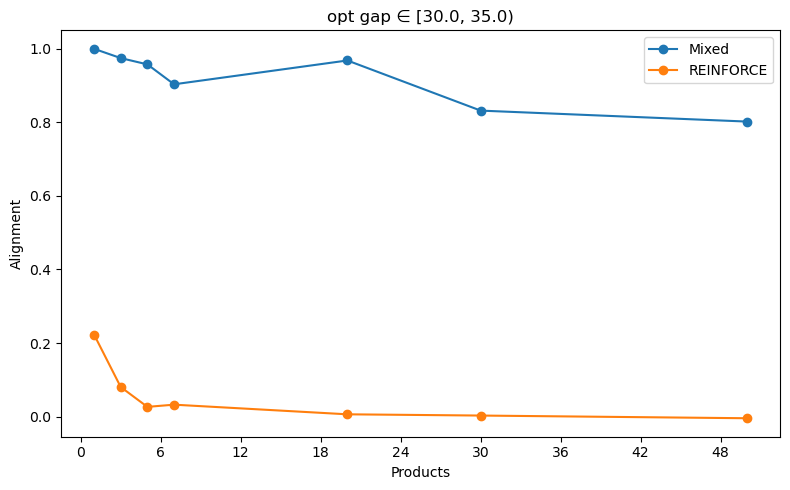

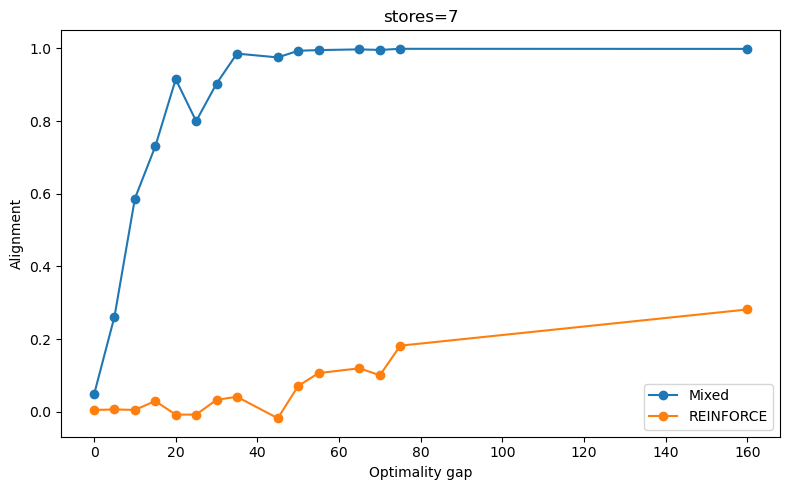

In [30]:
if __name__ == "__main__":

# Plot alignment metrics
    plot_metric_vs_x(
        df=bucketed_df,
        x_key="stores",
        filter_key="bucket_left",
        filter_value=BUCKET,
        value_metrics=vm,
        bucket_width=BUCKET_WIDTH,
        ylabel=ylabel,
        xlabel="Products",
        legend_names=legend_names,
    )

    plot_metric_vs_x(
        df=bucketed_df,
        x_key="bucket_left",
        xlabel="Optimality gap",
        filter_key="stores",
        filter_value=stores,
            value_metrics=vm,
        bucket_width=BUCKET_WIDTH,
        ylabel=ylabel,
        xlim=xlim,
        ylim=ylim,
        legend_names=legend_names,
    )

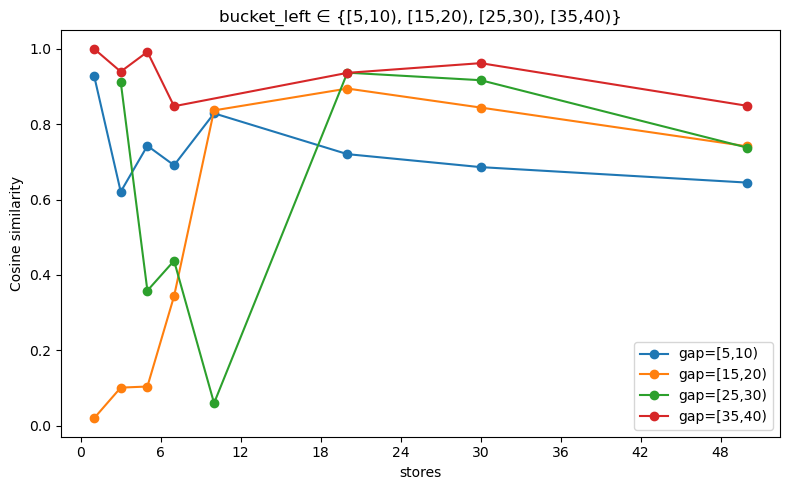

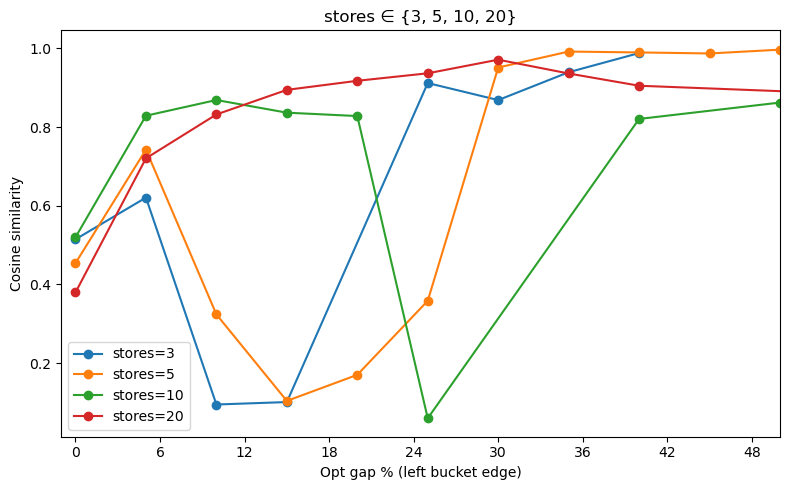

In [9]:
if __name__ == "__main__":

    # Compare multiple opt-gap buckets, x=stores
    plot_metric_vs_x_multi(
        df=bucketed_df,
        x_key="stores",
        filter_key="bucket_left",
        filter_values=[5.0, 15.0, 25.0, 35.0],
        value_metrics=vm,
        bucket_width=BUCKET_WIDTH,
        ylabel=ylabel,
    )

    # Compare multiple store counts, x=opt-gap bucket
    plot_metric_vs_x_multi(
        df=bucketed_df,
        x_key="bucket_left",
        xlabel="Opt gap % (left bucket edge)",
        filter_key="stores",
        filter_values=[3, 5, 10, 20],
        # filter_values=[3, 10, 30, 50],
        value_metrics=vm,
        bucket_width=BUCKET_WIDTH,
        ylabel=ylabel,
        xlim=[-1,50],
        ylim=ylim,
    )

/tmp/ipykernel_118463/1347572244.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap         = plt.cm.get_cmap(cmap_name)


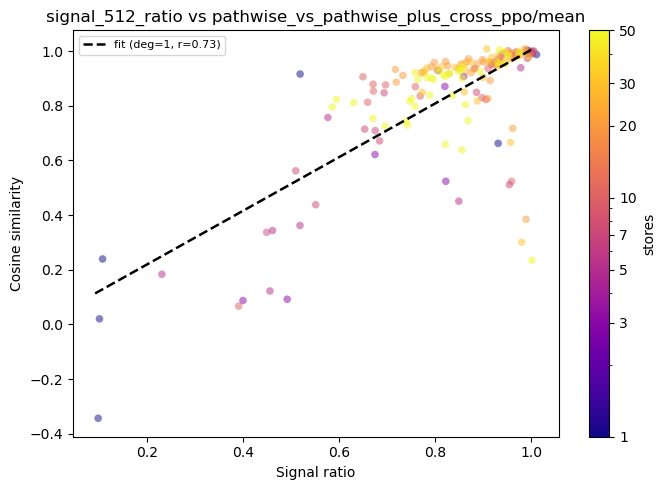

In [34]:
plot_scatter_with_regression(
    df=bucketed_df,
    x_metric=f"signal_{d}_ratio",
    y_metric=f"train/loo_cosine_{d}/continuous/pathwise_vs_pathwise_plus_cross_ppo/mean",
    color_key="stores",
    bucket_width=BUCKET_WIDTH,
    filter_key=None,
    filter_value=None,
    xlabel="Signal ratio",
    ylabel="Cosine similarity",
    show_regression=True,
    regression_degree=1,       # quadratic looks better for a saturating relationship
    # regime_x=(0.85, 1.0),      # shade the region where your experiments actually live
    point_size=30,
    alpha=0.5,
    jitter=0.01,
    cmap_name="plasma",
)

### Empirical performance

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import wandb
from scipy import stats as scipy_stats
 
WANDB_ENTITY = "alvomatias_project"
WANDB_PROJECT = "inventory_control"
PERFORMANCE_METRIC = "test/loss/reported"
 
 
# ---------------------------------------------------------------------------
# Data fetching
# ---------------------------------------------------------------------------
 
def fetch_sweep_runs(
    sweep_name: str,
    wandb_project: str = WANDB_PROJECT,
) -> list:
    api = wandb.Api()
    sweep = api.sweep(f"{WANDB_ENTITY}/{wandb_project}/{sweep_name}")
    runs = list(sweep.runs)
    print(f"Fetched {len(runs)} runs from sweep {sweep_name}")
    return runs
 
 
def fetch_agent_performance(
    sweep_names: list[str],
    metric: str = PERFORMANCE_METRIC,
    x_key: str = "stores",
    group_key: str | None = None,
    agent_rename: dict[str, str] | None = None,
    wandb_project: str = WANDB_PROJECT,
    filters: dict | None = None,
    loss_multiplier_keys: list[str] | None = None,  # list of config keys (dot-separated
                                                      # for nested) whose values multiply
                                                      # the metric. e.g.:
                                                      # ["stores",
                                                      #  "setting_config.params_by_dataset.test.periods"]
) -> pd.DataFrame:
    """
    Fetches runs from one or more sweeps and returns a DataFrame with one row
    per run containing the agent type, x_key value, optional group_key value,
    and metric value.
 
    Parameters
    ----------
    sweep_names    : list of W&B sweep IDs
    metric         : scalar metric to fetch (e.g. "test/loss/reported")
    x_key          : config key for the x-axis grouping (e.g. "stores")
    group_key      : optional config key to use as a secondary grouping dimension
                     that produces separate lines (e.g. "n_modes"). If None,
                     lines are split by agent type only.
    agent_rename   : optional dict mapping raw agent_type -> display name
    wandb_project  : W&B project name (overrides module-level WANDB_PROJECT)
    filters        : optional dict of config-key -> value or (min, max) range
                     used to include only matching runs. Examples:
                       {"stores": 40}            # exact match
                       {"stores": (None, 40)}    # stores <= 40
                       {"stores": (8, 32)}       # 8 <= stores <= 32
                       {"n_modes": [2, 4]}       # stores in list
    loss_multiplier_keys : optional list of config keys whose values are
                           multiplied into the metric before aggregation.
                           Keys may be dot-separated for nested config fields.
                           e.g. ["stores",
                                 "setting_config.params_by_dataset.test.periods"]
                           applies metric *= p * T.
 
    Returns
    -------
    pd.DataFrame with columns: agent, {x_key}, [{group_key}], metric_value
    """
    if agent_rename is None:
        agent_rename = {}
    if filters is None:
        filters = {}
 
    def _passes_filter(cfg: dict) -> bool:
        for fkey, fval in filters.items():
            if fkey not in cfg:
                return False
            v = cfg[fkey]
            if isinstance(fval, (list, set)):
                if v not in fval:
                    return False
            elif isinstance(fval, tuple):
                lo, hi = fval
                if lo is not None and v < lo:
                    return False
                if hi is not None and v > hi:
                    return False
            else:  # exact match
                if v != fval:
                    return False
        return True
 
    records = []
    seen_run_ids = set()
 
    for sweep_name in sweep_names:
        runs = fetch_sweep_runs(sweep_name, wandb_project=wandb_project)
        for run in runs:
            if run.id in seen_run_ids:
                continue
            seen_run_ids.add(run.id)
 
            cfg = run.config
 
            # --- apply filters ---
            if not _passes_filter(cfg):
                continue
 
            # --- extract agent type ---
            try:
                agent_type = cfg["hyperparams_config"]["agent_params"]["agent_type"]
            except (KeyError, TypeError):
                print(f"Skipping run {run.id}: could not find agent_type in hyperparams_config")
                continue
 
            # --- extract x_key ---
            if x_key not in cfg:
                print(f"Skipping run {run.id}: missing config key '{x_key}'")
                continue
            x_val = cfg[x_key]
 
            # --- extract optional group_key ---
            group_val = None
            if group_key is not None:
                if group_key not in cfg:
                    print(f"Skipping run {run.id}: missing config key '{group_key}'")
                    continue
                group_val = cfg[group_key]
 
            # --- extract metric summary value ---
            metric_val = run.summary.get(metric)
            if metric_val is None:
                print(f"Skipping run {run.id} ({agent_type}, {x_key}={x_val}): "
                      f"metric '{metric}' not in summary")
                continue
 
            agent_label = agent_rename.get(agent_type, agent_type)
            metric_val_scaled = float(metric_val)
            if loss_multiplier_keys:
                for mkey in loss_multiplier_keys:
                    # support dot-separated nested keys, e.g.
                    # "setting_config.params_by_dataset.test.periods"
                    parts = mkey.split(".")
                    node = cfg
                    val = None
                    try:
                        for part in parts:
                            node = node[part]
                        val = node
                    except (KeyError, TypeError):
                        pass
                    if val is not None:
                        metric_val_scaled *= float(val)
                    else:
                        print(f"Warning: run {run.id} missing multiplier key "
                              f"'{mkey}', skipping it")
            record = {
                "agent": agent_label,
                x_key: x_val,
                "metric_value": metric_val_scaled,
            }
            if group_key is not None:
                record[group_key] = group_val
            records.append(record)
 
    df = pd.DataFrame(records)
    print(f"\nTotal valid runs: {len(df)}")
    if not df.empty:
        group_cols = ["agent", x_key] + ([group_key] if group_key else [])
        print(df.groupby(group_cols).size().rename("n_runs").to_string())
    return df
 
 
# ---------------------------------------------------------------------------
# Aggregation
# ---------------------------------------------------------------------------
 
def compute_performance_stats(
    df: pd.DataFrame,
    x_key: str = "stores",
    group_key: str | None = None,
    aggregation: str = "mean",
    relative: bool = False,
    exclude_baseline: bool = False,
    baseline_agent: str | None = None,
    exclude_points: list[tuple] | None = None,
    ci_level: float = 0.95,
) -> pd.DataFrame:
    """
    Computes aggregated performance and confidence interval for each
    (agent, x_key, [group_key]) combination.
 
    Parameters
    ----------
    df               : output of fetch_agent_performance
    x_key            : grouping dimension for x-axis (e.g. "stores")
    group_key        : optional secondary grouping dimension (e.g. "n_modes")
    aggregation      : one of "mean", "median", "min"
                       - "mean"   : mean ± z * se  (standard CI)
                       - "median" : median with 95% bootstrap CI
                       - "min"    : minimum value, no CI
    relative         : if True, express performance relative to the baseline
                       agent for each (x_key, [group_key]) combination:
                           rel = (value / baseline_value - 1) * 100
                       If no baseline_agent is set, uses the global minimum
                       across all agents as the denominator (original behaviour).
    exclude_baseline : if True, drop the baseline agent from the returned
                       DataFrame (useful when relative=True and you only want
                       to show how other agents compare to it)
    baseline_agent   : display name of the agent to use as the baseline for
                       relative comparisons (e.g. "HPO"). Required when
                       relative=True and exclude_baseline=True; also used
                       for relative normalisation when provided.
    exclude_points   : list of (x_val, group_val) tuples to drop before
                       aggregation. group_val is only used when group_key is
                       set; pass None as group_val to exclude an x_val across
                       all groups. Examples:
                         [(40, 2)]          # drop x=40, group=2
                         [(40, None)]       # drop x=40 for all groups
                         [(40, 2), (48, 6)] # drop two specific cells
    ci_level         : confidence level (default 0.95)
 
    Returns
    -------
    pd.DataFrame with columns:
        agent, {x_key}, [{group_key}], center, ci_lo, ci_hi, n
    where center is the mean / median / min depending on `aggregation`.
    """
    result_df = df.copy()
 
    # ── exclude specific (x, group) cells ────────────────────────────────────
    if exclude_points:
        for point in exclude_points:
            x_val = point[0]
            g_val = point[1] if len(point) > 1 else None
            mask = result_df[x_key] == x_val
            if group_key is not None and g_val is not None:
                mask &= result_df[group_key] == g_val
            n_dropped = mask.sum()
            if n_dropped > 0:
                gstr = f", {group_key}={g_val}" if (group_key and g_val is not None) else ""
                print(f"Excluding {n_dropped} rows at {x_key}={x_val}{gstr}")
            result_df = result_df[~mask]
    group_cols = ["agent", x_key] + ([group_key] if group_key else [])
    x_group_cols = [x_key] + ([group_key] if group_key else [])
    z = scipy_stats.norm.ppf(0.5 + ci_level / 2)
 
    # ── relative normalisation ────────────────────────────────────────────────
    if relative:
        if baseline_agent is not None:
            # normalise by the *aggregated* baseline value per (x, [group])
            def _agg(vals):
                if aggregation == "median":
                    return np.median(vals)
                elif aggregation == "min":
                    return np.min(vals)
                else:
                    return np.mean(vals)
 
            baseline_df = (
                result_df[result_df["agent"] == baseline_agent]
                .groupby(x_group_cols)["metric_value"]
                .apply(_agg)
                .rename("baseline_val")
                .reset_index()
            )
            result_df = result_df.merge(baseline_df, on=x_group_cols, how="left")
        else:
            # original behaviour: global min per x group
            best_per_x = (
                result_df.groupby(x_group_cols)["metric_value"]
                .min()
                .rename("baseline_val")
                .reset_index()
            )
            result_df = result_df.merge(best_per_x, on=x_group_cols, how="left")
 
        result_df["metric_value"] = (
            result_df["metric_value"] / result_df["baseline_val"] - 1.0
        ) * 100.0
        result_df = result_df.drop(columns=["baseline_val"])
 
    # ── exclude baseline agent ────────────────────────────────────────────────
    if exclude_baseline and baseline_agent is not None:
        result_df = result_df[result_df["agent"] != baseline_agent]
 
    # ── aggregation ───────────────────────────────────────────────────────────
    records = []
    for keys, grp in result_df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        key_dict = dict(zip(group_cols, keys))
        vals = grp["metric_value"].dropna().values
        n = len(vals)
 
        if aggregation == "mean":
            center = vals.mean()
            se = vals.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
            ci_lo = center - z * se
            ci_hi = center + z * se
 
        elif aggregation == "median":
            center = np.median(vals)
            if n > 1:
                boots = [
                    np.median(np.random.choice(vals, size=n, replace=True))
                    for _ in range(2000)
                ]
                ci_lo, ci_hi = np.percentile(boots, [100*(1-ci_level)/2,
                                                      100*(1+ci_level)/2])
            else:
                ci_lo = ci_hi = center
 
        elif aggregation == "min":
            center = vals.min()
            ci_lo = ci_hi = center  # no meaningful CI for min
 
        else:
            raise ValueError(f"aggregation must be 'mean', 'median', or 'min'; got '{aggregation}'")
 
        records.append({**key_dict, "center": center, "ci_lo": ci_lo, "ci_hi": ci_hi, "n": n})
 
    stats_df = (
        pd.DataFrame(records)
        .sort_values(group_cols)
        .reset_index(drop=True)
    )
    return stats_df
 
 
# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------
 
def plot_agent_comparison(
    sweep_names: list[str],
    metric: str = PERFORMANCE_METRIC,
    x_key: str = "stores",
    group_key: str | None = None,
    aggregation: str = "mean",
    relative: bool = False,
    exclude_baseline: bool = False,
    baseline_agent: str | None = None,
    agent_rename: dict[str, str] | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    title: str | None = None,
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    ci_level: float = 0.95,
    wandb_project: str = WANDB_PROJECT,
    filters: dict | None = None,
    exclude_points: list[tuple] | None = None,
    # ── figure aesthetics ────────────────────────────────────────────────────
    figsize: tuple = (5.5, 3.5),       # NeurIPS two-column friendly default
    font_size: int = 11,               # base font size for labels and ticks
    legend_font_size: int | None = None,  # defaults to font_size - 1
    line_width: float = 1.8,
    marker_size: float = 4.5,
    ci_alpha: float = 0.12,            # opacity of confidence band
    grid_alpha: float = 0.15,          # lighter grid for publication
    dpi: int = 300,                    # high-res output
    agent_colors: dict | None = None,  # override per-agent colours
    agent_linestyles: dict | None = None,  # override per-agent linestyles
    group_label_fmt: str | None = None,
    show_title: bool = False,
    loss_multiplier_keys: list[str] | None = None,  # e.g. ["stores", "setting_config.params_by_dataset.test.periods"]
    out_file: str | None = None,
) -> pd.DataFrame:
    """
    Fetches runs from one or more sweeps and plots aggregated performance
    with confidence intervals.
 
    When group_key is None (default / original behaviour):
        One line per agent type — replicates the original function exactly.
 
    When group_key is set (e.g. group_key="n_modes"):
        One line per (agent × group_key) combination, with the agent
        indicated by line style and the group value by colour.
        If exclude_baseline=True, only non-baseline agents are shown and
        each line corresponds to one group_key value.
 
    Parameters
    ----------
    sweep_names         : list of W&B sweep IDs
    metric              : summary metric (e.g. "test/loss/reported")
    x_key               : config key for x-axis (e.g. "stores")
    group_key           : optional config key for secondary line grouping
                          (e.g. "n_modes"). None → original behaviour.
    aggregation         : "mean" | "median" | "min"
    relative            : express y as % above baseline
    exclude_baseline    : drop baseline agent from the plot
    baseline_agent      : display name of baseline agent (e.g. "HPO")
    agent_rename        : dict mapping raw agent_type -> display label
    xlabel / ylabel / title : axis labels and title
    xlim / ylim         : axis limits
    ci_level            : confidence level for shaded bands
    wandb_project       : W&B project name (overrides module-level WANDB_PROJECT)
    filters             : dict of config-key -> value / (min, max) / [list] to
                          restrict which runs are included. Applied before any
                          aggregation. Examples:
                            {"stores": (None, 40)}   # stores <= 40
                            {"stores": (8, 32)}       # 8 <= stores <= 32
                            {"n_modes": [2, 4]}       # only K=2 or K=4
    exclude_points      : list of (x_val, group_val) tuples identifying specific
                          (x_key, group_key) cells to drop before aggregation.
                          Useful for removing known diverged/unstable cells without
                          filtering an entire x or group value. Examples:
                            [(40, 2)]          # drop stores=40, n_modes=2
                            [(40, None)]       # drop stores=40 for all groups
                            [(40, 2), (48, 6)] # drop two cells
    figsize             : figure size in inches (default: (5.5, 3.5) for NeurIPS
                          two-column layout)
    font_size           : base font size for axis labels and tick labels
    legend_font_size    : legend font size (default: font_size - 1)
    line_width          : width of plotted lines
    marker_size         : size of line markers
    ci_alpha            : opacity of confidence interval shading
    grid_alpha          : opacity of background grid lines
    dpi                 : output resolution (use 300+ for publication)
    agent_colors        : dict mapping agent display name -> matplotlib color,
                          e.g. {"HPO": "#2166ac", "PPO": "#d6604d"}
    agent_linestyles    : dict mapping agent display name -> linestyle string,
                          e.g. {"HPO": "-", "PPO": "--"}
    group_label_fmt     : format string for group_key legend labels, with
                          ``{val}`` as the placeholder for the group value.
                          e.g. "$J={val}$" produces "$J=2$", "$J=4$", etc.
                          If None, falls back to "group_key=val".
    show_title          : if False (default), suppresses the plot title since
                          NeurIPS convention is to use the figure caption instead
    loss_multiplier_keys : optional list of config keys (dot-separated for
                          nested fields) whose values are multiplied into the
                          metric, e.g. ["stores",
                          "setting_config.params_by_dataset.test.periods"]
    out_file            : save path (e.g. "plot.pdf"). Use .pdf for vector output
                          suitable for LaTeX inclusion.
 
    Returns
    -------
    stats_df : aggregated DataFrame
    """
    # ── fetch ─────────────────────────────────────────────────────────────────
    raw_df = fetch_agent_performance(
        sweep_names=sweep_names,
        metric=metric,
        x_key=x_key,
        group_key=group_key,
        agent_rename=agent_rename,
        wandb_project=wandb_project,
        filters=filters,
        loss_multiplier_keys=loss_multiplier_keys,
    )
    if raw_df.empty:
        print("No data found.")
        return ""
    if raw_df.empty:
        print("No data found.")
        return raw_df
 
    # ── aggregate ─────────────────────────────────────────────────────────────
    np.random.seed(42)
    stats_df = compute_performance_stats(
        raw_df,
        x_key=x_key,
        group_key=group_key,
        aggregation=aggregation,
        relative=relative,
        exclude_baseline=exclude_baseline,
        baseline_agent=baseline_agent,
        exclude_points=exclude_points,
        ci_level=ci_level,
    )
 
    _legend_fs = legend_font_size if legend_font_size is not None else max(font_size - 1, 8)
 
    # ── build line keys ───────────────────────────────────────────────────────
    if group_key is not None:
        line_keys = (
            stats_df[["agent", group_key]]
            .drop_duplicates()
            .sort_values(["agent", group_key])
            .values.tolist()
        )
    else:
        line_keys = [[a] for a in sorted(stats_df["agent"].unique())]
 
    agents_sorted = sorted(stats_df["agent"].unique())
 
    # ── colour / linestyle resolution ────────────────────────────────────────
    # Publication-friendly defaults: colour-blind safe palette
    _default_colors = [
        "#2166ac", "#d6604d", "#4dac26", "#8073ac",
        "#e08214", "#01665e", "#f6e8c3", "#542788",
    ]
    _default_linestyles = ["-", "--", "-.", ":"]
 
    if group_key is not None:
        group_vals = sorted(stats_df[group_key].unique())
        group_color = {
            g: (agent_colors or {}).get(str(g), _default_colors[i % len(_default_colors)])
            for i, g in enumerate(group_vals)
        }
        _ls_map = agent_linestyles or {}
        agent_ls = {
            a: _ls_map.get(a, _default_linestyles[i % len(_default_linestyles)])
            for i, a in enumerate(agents_sorted)
        }
    else:
        _color_map = agent_colors or {}
        agent_color = {
            a: _color_map.get(a, _default_colors[i % len(_default_colors)])
            for i, a in enumerate(agents_sorted)
        }
        _ls_map = agent_linestyles or {}
        agent_ls = {
            a: _ls_map.get(a, "-")   # single agent per line → always solid
            for a in agents_sorted
        }
 
    # ── global rcParams for publication style ─────────────────────────────────
    plt.rcParams.update({
        "font.family": "serif",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.labelsize": font_size - 1,
        "ytick.labelsize": font_size - 1,
    })
 
    # ── plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)
 
    for key in line_keys:
        if group_key is not None:
            agent, gval = key
            mask = (stats_df["agent"] == agent) & (stats_df[group_key] == gval)
            color = group_color[gval]
            ls = agent_ls[agent]
            if group_label_fmt is not None:
                _glabel = group_label_fmt.format(val=gval)
            else:
                _glabel = f"{group_key}={gval}"
            label = (
                f"{agent}, {_glabel}"
                if len(agents_sorted) > 1
                else _glabel
            )
        else:
            agent = key[0]
            mask = stats_df["agent"] == agent
            color = agent_color[agent]
            ls = agent_ls[agent]
            label = agent
 
        sub = stats_df[mask].sort_values(x_key)
        ax.plot(
            sub[x_key], sub["center"],
            marker="o", label=label, color=color,
            linestyle=ls, lw=line_width, ms=marker_size,
            markeredgewidth=0.5, markeredgecolor="white",
        )
 
        if aggregation != "min":
            ax.fill_between(
                sub[x_key], sub["ci_lo"], sub["ci_hi"],
                alpha=ci_alpha, color=color, linewidth=0,
            )
 
    # ── labels / formatting ───────────────────────────────────────────────────
    ax.set_xlabel(
        xlabel if xlabel is not None else x_key,
        fontsize=font_size,
    )
 
    if ylabel is not None:
        _ylabel = ylabel
    elif relative:
        baseline_lbl = f" vs {baseline_agent}" if baseline_agent else ""
        _ylabel = f"% above baseline{baseline_lbl}"
    else:
        agg_label = {"mean": "Mean", "median": "Median", "min": "Min"}[aggregation]
        _ylabel = f"{agg_label} test loss"
    ax.set_ylabel(_ylabel, fontsize=font_size)
 
    if show_title:
        _title = title if title is not None else f"Agent comparison ({aggregation})"
        ax.set_title(_title, fontsize=font_size + 1)
 
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
 
    ax.grid(alpha=grid_alpha, linewidth=0.5, linestyle="--")
    ax.legend(
        fontsize=_legend_fs,
        framealpha=0.9,
        edgecolor="0.8",
        borderpad=0.6,
        handlelength=1.8,
    )
    fig.tight_layout(pad=0.5)
 
    if out_file:
        fig.savefig(out_file, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {out_file}")
    plt.show()
 
    return stats_df
 
 
# ---------------------------------------------------------------------------
# LaTeX table generation
# ---------------------------------------------------------------------------
 
def generate_latex_table(
    sweep_names: list[str],
    metric: str = PERFORMANCE_METRIC,
    x_key: str = "stores",
    group_key: str | None = None,
    agent_rename: dict[str, str] | None = None,
    wandb_project: str = WANDB_PROJECT,
    filters: dict | None = None,
    exclude_points: list[tuple] | None = None,
    agents_order: list[str] | None = None,
    x_label: str | None = None,
    group_key_label: str | None = None,  # display name for group_key column header
                                          # e.g. "$J$" instead of "n_modes"
    group_label_fmt: str | None = None,
    caption: str = "Performance results.",
    label: str = "tab:results",
    float_fmt: str = ".3f",
    loss_multiplier_keys: list[str] | None = None,
) -> str:
    """
    Generates a LaTeX table with double headers (one per agent) and columns
    Mean ± Std, Median, Min for each agent. Rows are indexed by x_key
    (and optionally group_key).
 
    Parameters
    ----------
    sweep_names     : list of W&B sweep IDs
    metric          : summary metric to use
    x_key           : config key for row grouping (e.g. "stores")
    group_key       : optional secondary row grouping (e.g. "n_modes").
                      When set, rows are (x_key, group_key) pairs.
    agent_rename    : dict mapping raw agent_type -> display label
    wandb_project   : W&B project name
    filters         : row-level filters (same syntax as plot_agent_comparison)
    exclude_points  : list of (x_val, group_val) cells to drop
    agents_order    : order in which agents appear as column groups.
                      Defaults to alphabetical. e.g. ["HPO", "PPO"]
    x_label         : display name for the x_key column header
    group_label_fmt : format string for group_key values in the row index,
                      e.g. "$J={val}$". If None, raw value is used.
    caption         : LaTeX table caption
    label           : LaTeX table label
    float_fmt       : Python format spec for numeric values, e.g. ".3f"
 
    Returns
    -------
    str : LaTeX table source, ready to paste into a .tex file
    """
    # ── fetch raw data ────────────────────────────────────────────────────────
    raw_df = fetch_agent_performance(
        sweep_names=sweep_names,
        metric=metric,
        x_key=x_key,
        group_key=group_key,
        agent_rename=agent_rename,
        wandb_project=wandb_project,
        filters=filters,
        loss_multiplier_keys=loss_multiplier_keys,
    )
 
    # ── apply exclude_points ──────────────────────────────────────────────────
    if exclude_points:
        for point in exclude_points:
            x_val = point[0]
            g_val = point[1] if len(point) > 1 else None
            mask = raw_df[x_key] == x_val
            if group_key is not None and g_val is not None:
                mask &= raw_df[group_key] == g_val
            raw_df = raw_df[~mask]
 
    # ── compute per-group stats ───────────────────────────────────────────────
    row_keys = [x_key] + ([group_key] if group_key else [])
    agents = agents_order or sorted(raw_df["agent"].unique())
 
    records = []
    for keys, grp in raw_df.groupby(["agent"] + row_keys):
        if not isinstance(keys, tuple):
            keys = (keys,)
        agent = keys[0]
        row_vals = dict(zip(row_keys, keys[1:]))
        vals = grp["metric_value"].dropna().values
        n = len(vals)
        records.append({
            "agent": agent,
            **row_vals,
            "mean": vals.mean(),
            "std":  vals.std(ddof=1) if n > 1 else 0.0,
            "median": np.median(vals),
            "min":  vals.min(),
            "n":    n,
        })
 
    stats_df = pd.DataFrame(records)
 
    # ── determine unique row index values ─────────────────────────────────────
    row_index = (
        stats_df[row_keys]
        .drop_duplicates()
        .sort_values(row_keys)
        .values.tolist()
    )
 
    # ── helpers ───────────────────────────────────────────────────────────────
    def _fmt(v: float) -> str:
        return format(v, float_fmt)
 
    def _row_cells(vals: list) -> list[str]:
        parts = []
        for key, v in zip(row_keys, vals):
            if key == group_key and group_label_fmt is not None:
                parts.append(group_label_fmt.format(val=v))
            else:
                parts.append(str(v))
        return parts
 
    # ── build LaTeX ───────────────────────────────────────────────────────────
    n_agents = len(agents)
    n_metric_cols = 3   # mean±std, median, min
    n_row_cols = len(row_keys)
    total_cols = n_row_cols + n_agents * n_metric_cols
 
    col_spec = "l" * n_row_cols + ("rrr" * n_agents)
    _xl = x_label if x_label is not None else x_key
    _gl = group_key_label if group_key_label is not None else (
        f"${group_key}$" if group_key and "_" in group_key else group_key
    )
    row_headers = [_xl] + ([_gl] if group_key else [])
 
    lines = []
    lines.append(r"\begin{table}[ht]")
    lines.append(r"  \centering")
    lines.append(r"  \small")
    lines.append(f"  \\caption{{{caption}}}")
    lines.append(f"  \\label{{{label}}}")
    lines.append(f"  \\begin{{tabular}}{{{col_spec}}}")
    lines.append(r"    \toprule")
 
    # ── top header row: agent names spanning 3 cols each ─────────────────────
    row_placeholder = " & " * n_row_cols  # empty cells for row-index cols
    agent_headers = " & ".join(
        f"\\multicolumn{{3}}{{c}}{{\\textbf{{{a}}}}}" for a in agents
    )
    lines.append(f"    {row_placeholder.rstrip('& ').rstrip()} & {agent_headers} \\\\")
 
    # cmidrule under each agent block
    cmidrules = []
    for i, _ in enumerate(agents):
        start = n_row_cols + i * n_metric_cols + 1  # 1-indexed
        end   = start + n_metric_cols - 1
        cmidrules.append(f"\\cmidrule(lr){{{start}-{end}}}")
    lines.append("    " + " ".join(cmidrules))
 
    # ── second header row: metric names ──────────────────────────────────────
    def _safe_header(h: str) -> str:
        """Wrap in math mode if the header contains underscores or $, else textbf."""
        if "_" in h and not h.startswith("$"):
            return f"\\textbf{{${h}$}}"
        return f"\\textbf{{{h}}}"
 
    row_col_headers = " & ".join(_safe_header(h) for h in row_headers)
    metric_headers = " & ".join(
        ["\\textbf{Mean $\\pm$ Std} & \\textbf{Median} & \\textbf{Min}"] * n_agents
    )
    lines.append(f"    {row_col_headers} & {metric_headers} \\\\")
    lines.append(r"    \midrule")
 
    # ── data rows ─────────────────────────────────────────────────────────────
    for row_vals in row_index:
        if not isinstance(row_vals, list):
            row_vals = [row_vals]
        cells = _row_cells(row_vals)
 
        for agent in agents:
            mask = stats_df["agent"] == agent
            for key, v in zip(row_keys, row_vals):
                mask &= stats_df[key] == v
            sub = stats_df[mask]
 
            if sub.empty:
                cells += ["--", "--", "--"]
            else:
                r = sub.iloc[0]
                mean_std = f"${_fmt(r['mean'])} \\pm {_fmt(r['std'])}$"
                cells.append(mean_std)
                cells.append(f"${_fmt(r['median'])}$")
                cells.append(f"${_fmt(r['min'])}$")
 
        lines.append("    " + " & ".join(cells) + r" \\")
 
    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")
 
    return "\n".join(lines)


Fetched 88 runs from sweep xs0iw9x4
Skipping run 3vxdmd9i (hybrid, stores=50): metric 'test/loss/reported' not in summary
Skipping run mi60qvd1 (hybrid, stores=50): metric 'test/loss/reported' not in summary
Skipping run kg55b1eu (hybrid, stores=7): metric 'test/loss/reported' not in summary
Skipping run gcc9ohvf (hybrid, stores=30): metric 'test/loss/reported' not in summary
Skipping run x695iww2 (hybrid, stores=20): metric 'test/loss/reported' not in summary
Skipping run wrj9rosg (hybrid, stores=5): metric 'test/loss/reported' not in summary
Skipping run d1o4nlws (hybrid, stores=10): metric 'test/loss/reported' not in summary
Skipping run an50g0uv (hybrid, stores=7): metric 'test/loss/reported' not in summary
Fetched 88 runs from sweep 8yd4la7p
Skipping run a9jeiddn (gaussian_ppo, stores=1): metric 'test/loss/reported' not in summary
Skipping run zuqfibao (gaussian_ppo, stores=1): metric 'test/loss/reported' not in summary
Skipping run yavtefff (gaussian_ppo, stores=7): metric 'test/

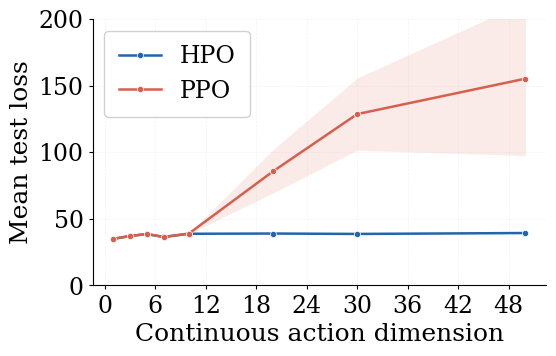

   agent  stores      center       ci_lo       ci_hi   n
0    HPO       1   34.942191   34.922932   34.961450  11
1    HPO       3   37.071001   37.052814   37.089189  11
2    HPO       5   38.569605   38.533413   38.605797  10
3    HPO       7   36.316195   36.272814   36.359575   9
4    HPO      10   38.746833   38.654732   38.838935  10
5    HPO      20   38.928066   38.819726   39.036407  10
6    HPO      30   38.629545   38.412756   38.846335  10
7    HPO      50   39.312127   39.027417   39.596838   9
8    PPO       1   34.919174   34.906316   34.932032   8
9    PPO       3   37.071005   37.060136   37.081875  10
10   PPO       5   38.546130   38.519037   38.573223  10
11   PPO       7   36.425051   36.384849   36.465252   9
12   PPO      10   38.929193   38.687126   39.171260  10
13   PPO      20   85.632744   69.379596  101.885893  10
14   PPO      30  128.561537  101.488458  155.634616  11
15   PPO      50  155.158531   97.442726  212.874335  11


In [ ]:

# ---------------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------------
if __name__ == "__main__":

    AGENT_RENAME = {
        "gaussian_ppo": "PPO",
        "hybrid":       "HPO",
    }

    # ── Original experiment: absolute performance, one line per agent ─────────
    SWEEP_NAMES_INVENTORY = [
        "xs0iw9x4",
        "8yd4la7p",
    ]

    stats_abs = plot_agent_comparison(
        sweep_names=SWEEP_NAMES_INVENTORY,
        wandb_project="inventory_control",
        metric="test/loss/reported",
        x_key="stores",
        aggregation="mean",          # "mean" | "median" | "min"
        relative=False,
        agent_rename=AGENT_RENAME,
        xlabel="Continuous action dimension",
        ylabel="Mean test loss",
        title="HPO vs PPO — heterogeneous setting",
        ci_level=0.95,
        out_file="performance_results_jrp.pdf",
        ylim=(0, 200),
        font_size=18,
    )
    print(stats_abs)    


Fetched 264 runs from sweep 6squair3
Skipping run mnljgr7f (hybrid, stores=40): metric 'test/loss/reported' not in summary
Skipping run bx6guoyw (hybrid, stores=8): metric 'test/loss/reported' not in summary
Skipping run a5sljckx (hybrid, stores=16): metric 'test/loss/reported' not in summary
Skipping run 9zdcnkcn (hybrid, stores=24): metric 'test/loss/reported' not in summary
Skipping run bj39s3y7 (hybrid, stores=32): metric 'test/loss/reported' not in summary
Skipping run y8i8txyj (hybrid, stores=40): metric 'test/loss/reported' not in summary
Fetched 264 runs from sweep 1fbr2bkg
Skipping run vi5pcyy3 (gaussian_ppo, stores=16): metric 'test/loss/reported' not in summary
Skipping run dgx50ud2 (gaussian_ppo, stores=32): metric 'test/loss/reported' not in summary
Skipping run 7foast0g (gaussian_ppo, stores=24): metric 'test/loss/reported' not in summary
Skipping run egchk6qh (gaussian_ppo, stores=32): metric 'test/loss/reported' not in summary
Skipping run hyod8hgx (gaussian_ppo, stores

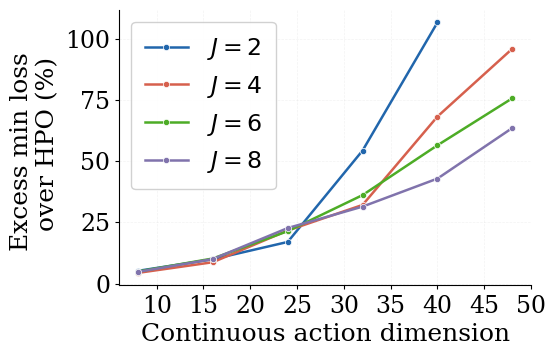

   agent  stores  n_modes      center       ci_lo       ci_hi   n
0    PPO       8        2    5.161587    5.161587    5.161587  11
1    PPO       8        4    4.335902    4.335902    4.335902  11
2    PPO       8        6    4.885322    4.885322    4.885322  11
3    PPO       8        8    4.748076    4.748076    4.748076  11
4    PPO      16        2    9.895266    9.895266    9.895266  11
5    PPO      16        4    8.692626    8.692626    8.692626  11
6    PPO      16        6   10.211198   10.211198   10.211198  10
7    PPO      16        8    9.990709    9.990709    9.990709  11
8    PPO      24        2   16.976234   16.976234   16.976234  11
9    PPO      24        4   21.644200   21.644200   21.644200  11
10   PPO      24        6   21.387582   21.387582   21.387582  11
11   PPO      24        8   22.645680   22.645680   22.645680  10
12   PPO      32        2   54.326685   54.326685   54.326685  11
13   PPO      32        4   32.103399   32.103399   32.103399  11
14   PPO  

In [10]:
if __name__ == "__main__":

# ── LQR experiment: relative gap, one line per n_modes, HPO as baseline ──
    SWEEP_NAMES_LQR = [
        "6squair3",     # replace with real sweep IDs
        "1fbr2bkg",
    ]

    AGENT_RENAME = {
        "gaussian_ppo": "PPO",
        "hybrid":       "HPO",
    }
    
    stats_lqr = plot_agent_comparison(
        sweep_names=SWEEP_NAMES_LQR,
        wandb_project="lqr_switched",
        metric="test/loss/reported",
        x_key="stores",
        group_key="n_modes",         # one line per K value
        aggregation="min",          # mean loss; diverged runs inflate this naturally
        relative=True,               # express as % above HPO baseline
        exclude_baseline=True,       # only show PPO lines (HPO is the denominator)
        baseline_agent="HPO",
        agent_rename=AGENT_RENAME,
        exclude_points=[(48, 2)],          # drop stores=40, K=2 (PPO diverged in all seeds)
        group_label_fmt="$J={val}$",       # renders as $J=2$, $J=4$, etc. in legend
        xlabel="Continuous action dimension",
        ylabel="Excess min loss \n over HPO (%)",
        title="PPO vs Hybrid: relative gap grows with continuous action dimension",
        ci_level=0,
        out_file="performance_results_lqr.pdf",
        font_size=18,
    )
    print(stats_lqr)

In [27]:
if __name__ == "__main__":
    # ── JRP table ─────────────────────────────────────────────────────────────
    jrp_table = generate_latex_table(
        sweep_names=SWEEP_NAMES_INVENTORY,
        wandb_project="inventory_control",
        metric="test/loss/reported",
        x_key="stores",
        agent_rename=AGENT_RENAME,
        agents_order=["HPO", "PPO"],   # HPO columns first
        x_label="$J$",
        caption="JRP test loss across product counts. Mean $\\pm$ std, median, and "
                "minimum over 10 independent trials.",
        label="tab:jrp-results",
        float_fmt=".2f",
    )
    print(jrp_table)

Fetched 88 runs from sweep xs0iw9x4
Skipping run 3vxdmd9i (hybrid, stores=50): metric 'test/loss/reported' not in summary
Skipping run mi60qvd1 (hybrid, stores=50): metric 'test/loss/reported' not in summary
Skipping run kg55b1eu (hybrid, stores=7): metric 'test/loss/reported' not in summary
Skipping run gcc9ohvf (hybrid, stores=30): metric 'test/loss/reported' not in summary
Skipping run x695iww2 (hybrid, stores=20): metric 'test/loss/reported' not in summary
Skipping run wrj9rosg (hybrid, stores=5): metric 'test/loss/reported' not in summary
Skipping run d1o4nlws (hybrid, stores=10): metric 'test/loss/reported' not in summary
Skipping run an50g0uv (hybrid, stores=7): metric 'test/loss/reported' not in summary
Fetched 88 runs from sweep 8yd4la7p
Skipping run a9jeiddn (gaussian_ppo, stores=1): metric 'test/loss/reported' not in summary
Skipping run zuqfibao (gaussian_ppo, stores=1): metric 'test/loss/reported' not in summary
Skipping run yavtefff (gaussian_ppo, stores=7): metric 'test/

In [42]:
if __name__ == "__main__":
    # ── S-LQR table (rows indexed by (p, J)) ─────────────────────────────────
    lqr_table = generate_latex_table(
        sweep_names=SWEEP_NAMES_LQR,
        wandb_project="lqr_switched",
        metric="test/loss/reported",
        x_key="stores",
        group_key="n_modes",
        agent_rename=AGENT_RENAME,
        agents_order=["HPO", "PPO"],
        # filters={"stores": (None, 40)},
        # exclude_points=[(40, 2)],
        x_label="$p$",
        group_key_label="$J$",
        group_label_fmt="$J={val}$",
        loss_multiplier_keys=[
            "stores",
            "setting_config.params_by_dataset.test.periods",
        ],
        caption="S-LQR test loss across action dimensions $p$ and modes $J$. "
                "Mean $\\pm$ std, median, and minimum over 10 independent trials.",
        label="tab:lqr-results",
        float_fmt=".2f",
    )
    print(lqr_table)

Fetched 264 runs from sweep 6squair3
Skipping run mnljgr7f (hybrid, stores=40): metric 'test/loss/reported' not in summary
Skipping run bx6guoyw (hybrid, stores=8): metric 'test/loss/reported' not in summary
Skipping run a5sljckx (hybrid, stores=16): metric 'test/loss/reported' not in summary
Skipping run 9zdcnkcn (hybrid, stores=24): metric 'test/loss/reported' not in summary
Skipping run bj39s3y7 (hybrid, stores=32): metric 'test/loss/reported' not in summary
Skipping run y8i8txyj (hybrid, stores=40): metric 'test/loss/reported' not in summary
Fetched 264 runs from sweep 1fbr2bkg
Skipping run vi5pcyy3 (gaussian_ppo, stores=16): metric 'test/loss/reported' not in summary
Skipping run dgx50ud2 (gaussian_ppo, stores=32): metric 'test/loss/reported' not in summary
Skipping run 7foast0g (gaussian_ppo, stores=24): metric 'test/loss/reported' not in summary
Skipping run egchk6qh (gaussian_ppo, stores=32): metric 'test/loss/reported' not in summary
Skipping run hyod8hgx (gaussian_ppo, stores